# Übung 5

**Gruppenname:**

*ESM*

Gehen Sie wie folgt vor:

1. Kopieren Sie jetzt dieses Jupyter Notebook in Ihren Ordner (`Abgaben/Team_WXYZ`)

2. Tragen Sie Ihren Gruppennamen auch ganz oben bei "Name Ihrer Gruppe" ein.

3. Bearbeiten Sie dann dieses Notebook. Falls Sie das Notebook im Browser bearbeiten, vergessen Sie nicht, es regelmäßig zu speichern (z.B. über `Strg + S` oder über `File -> Save and Checkpoint`).

### In dieser Übung ...

werden Sie einen echten Datenfall bearbeiten, der die Firma Tesla betrifft. In diesem Fall werden Sie sich mit dem Thema *Datenaufbereitung* und dessen Konsequenzen beschäftigen. Nach dieser Aufgabe werden Sie sich noch einmal mit explorativer Analyse und Zusammenhangsmaßen (wie beispielsweise der *Mutual Information*) beschäftigen.

### 5.1 Der Fall Tesla: Autopilot

* In diesem Datenfall üben Sie Ihre Fähigkeiten, Datensätze zu erschließen, aufzubereiten und auf Plausibilität zu prüfen.

Seit wenigen Jahren verstärken verschiedene Unternehmen und Startups ihre Bemühungen, autonome Fahrzeuge zu entwickeln. Solche selbststeuerenden Fahrzeuge versprechen eine Vielzahl neuer Anwendungen und haben das Potenzial, unser Verhältnis zu Autos zu verändern. Manche Visionäre sprechen bereits von "mobility as a service", bei der Autos nicht mehr besessen, sondern per App für eine Fahrt geliehen werden und selbstständig fahren.

Bei der Entwicklung von autonomen Fahrzeugen verfolgen verschiedene Hersteller eine schrittweise Strategie, nach der Assistenzfunktionen zum Parken oder für das Halten der Fahrspur nach und nach den Fahrern zur Verfügung gestellt werden. Tesla stellt den sogenannten *Autopilot* bereit, der das Feature *Autosteer* zum automatischen Halten der Fahrspur enthält.

[Im Jahr 2016 verunglückte Joshua Brown](https://www.nytimes.com/2016/07/02/business/joshua-brown-technology-enthusiast-tested-the-limits-of-his-tesla.html) in Florida in einem Tesla Model S, während das Autosteer Feature aktiviert war. Er war damit der erste (soweit bekannte) Todesfall, der in einem selbstfahrenden Auto eingetreten ist.

Die NHTSA, eine Bundesbehörde der USA im Bereich des Verkehrsministeriums, untersuchte den Fall und forderte Zahlen von Tesla an, die die Sicherheit des Autosteering Features belegen sollten. Anhand dieser Zahlen konnte die Behörde im Jahr 2017 folgende Feststellung machen:

![Abbildung](https://data.bialonski.de/ds/tesla_autosteer_nhtsa.png)

Die Anzahl der Airbag-Auslösungen dient dabei als ein Anhaltspunkt für die Anzahl der Unfälle. Dieser Auswertung zufolge reduziert *Autosteer* die Unfallwahrscheinlichkeit um 40%!

Der dieser Statistik zugrundeliegende Datensatz wurde aufgrund eines Antrags basierend auf dem Informationsfreiheitsgesetz der USA (Freedom of Information Act) verfügbar gemacht und steht Ihnen in dieser Übung zur Verfügung.

**Ihre Daten**

* Sie finden die Daten, die Sie für diese Übung benötigen, im Git Repository unter `data/tesla.xlsx`.


Wir werden die folgenden Eigenschaften [1-6] untersuchen:

1. Kilometerstand (in Meilen) bevor der Installation von Autosteer ("1l Previous Mileage before Autosteer Install").

   * Dieser Wert wurde abgelesen vor Installation von Autosteer.


2. Kilometerstand (in Meilen) nach der Installation von Autosteer ("1l Next Mileage after Autosteer Install")

   * Dieser Wert wurde abgelesen nach Installation von Autosteer.
   
   
3. Gefahrene Meilen vor Autosteer-Installation ("Miles before Autosteer")

   * Dieser Wert wurde von Tesla so angegeben.


4. Gefahrene Meilen nach Autosteer Installation ("Miles after Autosteer")

   * Dieser Wert wurde von Tesla so angegeben.


5. Airbag-Auslösungen vor Autosteer-Installation ("Airbag events before Autosteer")

   * Dieser Wert wurde von Tesla so angegeben.


6. Airbag-Auslösungen nach Autosteer-Installation ("Airbag events after Autosteer")

   * Dieser Wert wurde von Tesla so angegeben.




**Ihre Aufgaben**

Für die nachfolgenden Aufgaben benötigen Sie Ihre Neugier und etwas detektivisches Gespür.

(1) Betrachten Sie zunächst mit einer Tabellenkalkulation den oben hinterlegten Datensatz. Suchen Sie nach den oben erwähnten sechs Eigenschaften. 

   * Importieren Sie nun mithilfe von Pandas die oben sechs erwähnten Eigenschaften aus der Excel-Datei. Dabei kann es hilfreich sein, das entsprechende Sheet der Excel-Datei in Pandas anzugeben, aus dem Sie die Daten importieren müssen.

In [30]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

df = pd.read_excel("../data/tesla.xlsx")
cols = df.columns

def clean(df):
    df.drop(columns="Unnamed: 0", inplace=True, axis=1)
    df.drop(cols[1], inplace=True, axis=1)
    df.drop(columns="Unnamed: 2", inplace=True, axis=1)

    for i in range(21, 27):
        df.drop(columns=f"Unnamed: {i}", inplace=True, axis=1)

    for i in range(5, 19):
        df.drop(columns=f"Unnamed: {i}", inplace=True, axis=1) 


def rename_cols(df):
    cols = ["Miles_bf", "Miles_af", "AB_bf", "AB_af"]
    df.columns = cols

def drop_unnecessary_rows(df):
    df.drop([0, 1, 11, 12], axis=0, inplace=True)

def prepare_data(df):
    clean(df) 
    rename_cols(df)
    drop_unnecessary_rows(df)

df_clean = df.copy()
prepare_data(df_clean)

df_clean


,Miles_bf,Miles_af,AB_bf,AB_af
2,28214308,48130324,1.275948,0.768746
3,36438878,144530555,1.289831,0.864869
4,25,26912159,0,0.817474
5,64653211,219573038,1.283772,0.83799
6,8658,15039698,115.500116,0.332453
7,28214308,48130324,1.275948,0.768746
8,36438878,144530555,1.289831,0.864869
9,8683,41951857,115.167569,0.643595
10,64661869,234612736,1.299065,0.805583


(2) Von wie vielen Fahrzeugen wurden Daten erhoben? Nennen Sie die Anzahl der Fahrzeuge, indem Sie sie aus Ihren Daten aus Teilaufgabe (1) bestimmen.

Es wurden 8 Fahrzeuge untersucht

In [31]:
c = Counter(df[cols[1]])
keys = list(c.keys())[2:len(c.keys()) - 1:]
vals = list(c.values())[2::]

models = {
    "models": keys,
    "vals": vals[:2]
}

print(models)


{'models': ['Model S', 'Model X'], 'vals': [1, 1]}


(3) Reproduzieren Sie die beiden Zahlen der NHTSA Behörde der USA, d.h. berechnen Sie die Anzahl der Airbag-Auslösungen vor Autosteer-Installation pro 1 Million gefahrener Meilen und nach Autosteer-Installation pro 1 Million gefahrener Meilen und geben Sie sie an.

   * Wenn Sie nicht auf die Zahlen der NHTSA kommen, lesen Sie diesen [Rot-13](https://rot13.de/index.php) kodierten Hinweis: Süe qvr Orerpuahat ahgmra Fvr ovggr qvr Qngraervura qerv ovf frpuf jvr vz Nofpuavgg "Vuer Qngra" natrtrora.

(4) Bis hierher stimmen unsere Analysen mit der US-Behörde überein. Doch es gibt Ungereimtheiten in den Daten. Betrachten Sie dazu die Datenreihen 1 und 2, d.h. die Kilometerstände (in Meilen) der Fahrzeuge vor und nach der Installation von Autosteer. Vor der Installation von Autosteer wird der Kilometerstand erhoben; nach der Installation von Autosteer wird der Kilometerstand erhoben:

1. Welche Erwartungshaltung haben Sie an die beiden Datensätze? (1 Satz)

2. Explorieren Sie diese beiden Datensätze (Stichwort: Explorative Analyse). Was fällt Ihnen auf? (1 Satz)

Wenn Sie partout nicht mehr weiter kommen, gebe ich Ihnen einen Tipp: Jraa Fvr ibe qre Vafgnyyngvba iba Nhgbfgrre qra Xvybzrgrefgnaq nofpuervora jüeqra, haq anpu qre Vafgnyyngvba rorasnyyf qra Xvybzrfgrefgnaq abgvrera, jüeqra fvpu qvr orvqra Xvybzrgrefgäaqr hagrefpurvqra bqre fbyygra fvr tyrvpu frva?

(5) Problem 1: Identifizieren Sie anhand Ihrer Beobachtungen aus Schritt (4) die Fahrzeuge, bei denen Sie genau feststellen konnten, zu welchem Kilometerstand Autosteer tatsächlich installiert worden sein muss. Betrachten Sie **nur** die Fahrzeuge aus dieser Menge, für die tatsächlich gefahrenen Kilometer (mehr als 0) vor der Autosteer-Installation ausgewiesen wurden.

* Wie viele Fahrzeuge erfüllen die gerade genannten Kriterien?
* Bestimmen Sie die Anzahl der Airbag-Auslösungen pro gefahrenen 1 Million Meilen vor und nach der Installation von Autosteer. Geben Sie diese Zahlen an. Was stellen Sie fest? 
* Vergleichen Sie Ihre Zahlen mit den oben angegebenen Zahlen der NHTSA. Sehen Sie gleiche oder unterschiedliche Tendenzen?

(6) Problem 2: Identifizieren Sie anhand Ihrer Beobachtungen aus Schritt (4) die Fahrzeuge, bei denen Sie genau feststellen konnten, zu welchem Kilometerstand Autosteer tatsächlich installiert worden sein muss. Betrachten Sie nun alle Fahrzeuge aus dieser Menge, die **keine gefahrenen Kilometer vor der Autosteer-Installation** aufweisen.

* Wie viele Fahrzeuge erfüllen die gerade genannten Kriterien?
* Wie viele Airbag-Auslösungen vor der Installation von Autosteer beobachten Sie für diese Gruppe von Fahrzeugen?
* Welche Auswirkung hat Ihre Beobachtung auf die Größe der Anzahl an Airbag-Auslösungen pro 1 Million gefahrener Meilen, wie sie die NHTSA berechnet hat?

(7) Problem 3: Identifizieren Sie anhand Ihrer Beobachtungen aus Schritt (4) die Fahrzeuge, bei denen Sie **nicht** genau feststellen können, zu welchem Kilometerstand Autosteer tatsächlich installiert wurde. Betrachten Sie **nur** die Fahrzeuge aus dieser Menge, für die tatsächlich mehr als 0 gefahrene Kilometer vor der Autosteer-Installation ausgewiesen wurden.

1. Wie viele Autos sind in dieser Menge enthalten? Wie viele Airbag-Auslösungen sind in dieser Menge enthalten?
2. Bestimmen Sie die Gesamtanzahl der gefahrenen Meilen über alle Fahrzeuge dieser Menge, die zwischen dem Kilometerstand vor Autosteer-Installation und nach Autoinstallation gefahren wurden. Dies sind die "Gap"-Meilen, bei denen wir nicht wissen, zu welcher exakten Kilometerstandszahl Autosteer installiert wurde.
3. Bestimmen Sie die Gesamtanzahl aller Meilen dieser Menge, die vor der Autosteer-Installation gefahren wurden. 
4. Vergleichen Sie die Zahlen aus Schritt 7.2 und 7.3: Ist die gefahrene Gesamtmeilenzahl vor Autosteer-Installation deutlich größer oder kleiner als die Gesamtmeilenzahl der "Gap"-Meilen?

Welchen Schluss ziehen Sie für die Validität der NHTSA Untersuchung aus Ihren Beobachtungen aus diesem Schritt? (1-3 Sätze).

(8) Problem 4: Identifizieren Sie anhand Ihrer Beobachtungen aus Schritt (4) die Fahrzeuge, bei denen Sie **nicht** genau feststellen können, zu welchem Kilometerstand Autosteer tatsächlich installiert wurde. Betrachten Sie **nur** die Fahrzeuge aus dieser Menge, für die nur 0 gefahrene Kilometer vor der Autosteer-Installation ausgewiesen wurden.

1. Wie viele Autos sind in dieser Menge enthalten?
2. Wie viele Airbag-Auslösungen können Sie vor und nach der Autosteer-Installation feststellen?

Wie deuten Sie Ihre Beobachtungen hinsichtlich der Validität der NHTSA Untersuchung? (1-3 Sätze)

(9) Abschluss: Betrachten Sie Ihre Ergebnisse zu Problemen 1-4. Lässt sich aufgrund der vorliegenden Zahlen die Aussage treffen, dass durch Autosteer die Anzahl der Airbag-Auslösungen pro gefahrene 1 Million Meilen zurückgegangen ist und damit das Fahren sicherer geworden ist? Argumentieren Sie in wenigen Sätzen.

## 5.2 Multivariate explorative Analyse II (Palmer Pinguine & Parallel Coordinates Plots)

In dieser Übung untersuchen Sie Daten verschiedener Pinguin-Gattungen, die während einer Forschungsmission in der Antarktis an der [Palmer-Station](https://de.wikipedia.org/wiki/Palmer-Station) gesammelt wurden. Der Datensatz stammt aus einer [Publikation](https://doi.org/10.1371/journal.pone.0090081), die das Futtersuchverhalten der Tiere untersuchte. Sie werden die Daten mithilfe von [**Parallel Coordinates Plots**](https://de.wikipedia.org/wiki/Parallele_Koordinaten) (PCPs, ||-Plots) untersuchen. PCPs sind wirkungsvolle Instrumente für eine Exploration höherdimensionaler Räume, die Sie im Rahmen dieser Übung kennenlernen werden. Sie spielen in vielen explorativen Analysen eine Rolle, beispielsweise auch bei der [Parameterexploration](https://web.archive.org/web/20240423104335/https://docs.wandb.ai/guides/app/features/panels/parallel-coordinates) zum Training tiefer neuronaler Netze.

Es begrüßen Sie:

<img src="https://allisonhorst.github.io/palmerpenguins/reference/figures/lter_penguins.png" alt="Palmer Penguins" width="600" style="background-color: white"/>

**Ihre Daten**

* Sie finden die Daten, die Sie für diese Übung benötigen, im Git Repository unter `data/palmerpenguins.csv`.

(1) Untersuchen Sie den Datensatz und beantworten Sie bitte folgende Fragen:
- Welche Features sind enthalten? 6
- Wie viele Datenpunkte gibt es? 343
- Wie viele Klassen (`species`) gibt es? 3
- Wie viele Datenpunkte gibt es pro Klasse?
    - Adelie: 152
    - Chinstrap: 68
    - Gentoo: 123

In [32]:
import seaborn as sb
ps = pd.read_csv('./../data/palmerpenguins.csv')
ps.dropna()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0
...,...,...,...,...,...,...
339,Chinstrap,Dream,55.8,19.8,207.0,4000.0
340,Chinstrap,Dream,43.5,18.1,202.0,3400.0
341,Chinstrap,Dream,49.6,18.2,193.0,3775.0
342,Chinstrap,Dream,50.8,19.0,210.0,4100.0


(2) Erstellen Sie einen Scatter-Matrix-Plot des oben beschriebenen Datensatzes, **wobei jeder Datenpunkt durch eine Farbe entsprechend der Spezies gekennzeichnet wird**. <br/>
Verwenden Sie dazu die Bibliothek `seaborn` und die Funktion [`pairplot`](https://seaborn.pydata.org/generated/seaborn.pairplot.html).

*Hinweis: `pairplot` interpretiert die numerischen Spalten des Datensatzes automatisch als Features. Aus diesem Grund erscheinen nicht zwingend alle Spalten im Scatter-Matrix-Plot.*

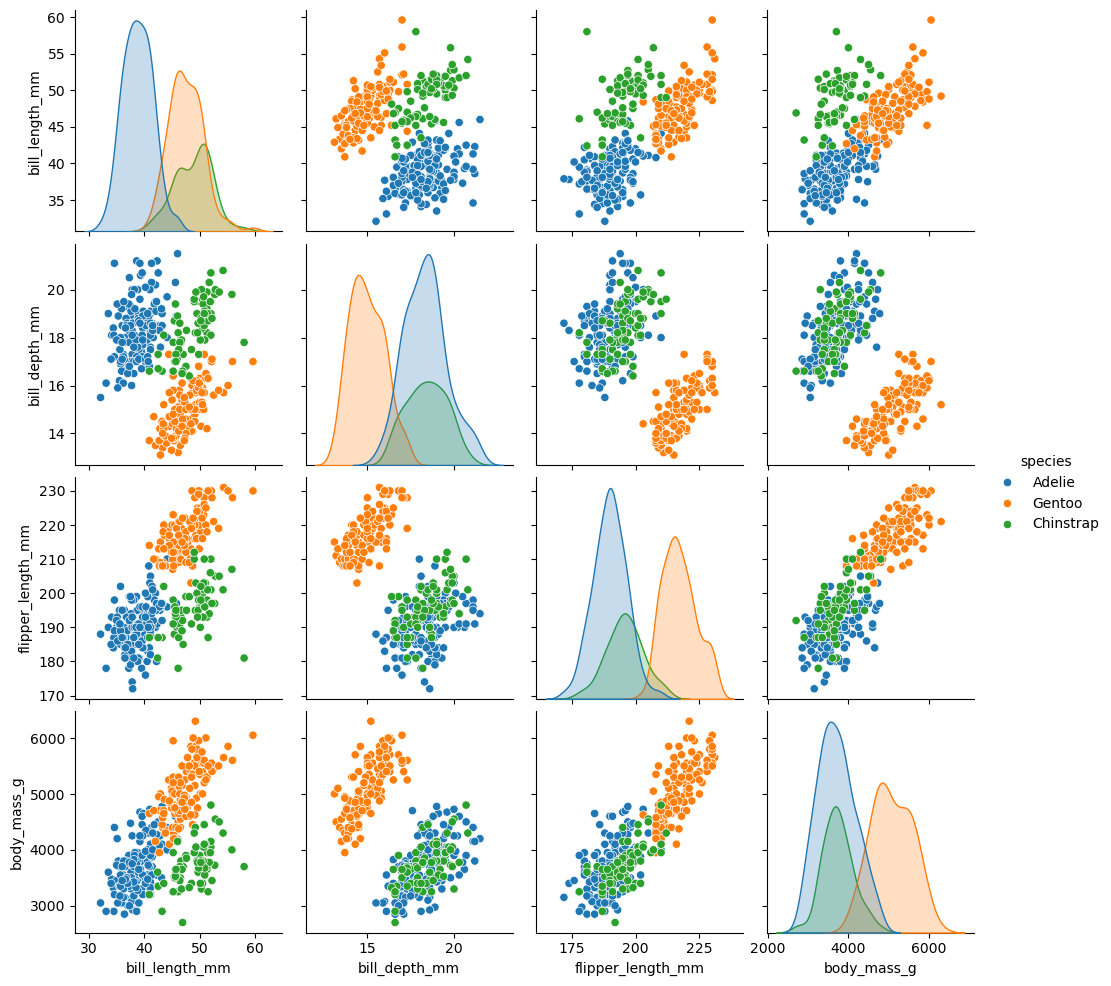

In [33]:
sb.pairplot(ps, hue='species')

*Falls Sie wissen möchten, was es mit dem sogenannten "Bill" auf sich hat:*

<img src="https://allisonhorst.github.io/palmerpenguins/reference/figures/culmen_depth.png" alt="Palmer Penguins" width="600"/>

(4) Die drei Pinguingattungen erscheinen im Scatter-Matrix-Plot der vorherigen Teilaufgabe als "Punktwolken" (mehr dazu in einer späteren Vorlesungseinheit zum Thema *Clustering*).

- Versuchen Sie nun, die drei Gattungen mithilfe sogenannter "Bounding Boxes" in den Plots zu identifizieren. Suchen Sie dazu nach Featurepaaren, in denen sich die Klassen gut voneinander unterscheiden lassen. Für jede "Bounding Box" benötigen Sie jeweils ein Intervall für die x- und y-Achse, welche die Punktwolke einer Gattung möglichst gut einschließt. 

Fiktives Beispiel:
- Gattung A: `body_mass_g` $\in [3000, 5000]$ und `flipper_length_mm` $\in [170, 200]$

- **Adelie**: bill_length_mm $\in [30, 40]$ und bill_depth_mm $\in [15, 20]$

- **Gentoo**:

- **Chinstrap**:

(5) Erstellen Sie einen Parallel Coordinates Plot (||-Plot) des oben beschriebenen Datensatzes. <br/>

1. Erstellen Sie einen Parallel Coordinates Plot mit `pandas.plotting.parallel_coordinates`. (Alternativ können Sie auch das Paket [`hiplot`](https://ai.meta.com/blog/hiplot-high-dimensional-interactive-plots-made-easy/) und die Funktionen [`Experiment.from_dataframe`](https://facebookresearch.github.io/hiplot/py_reference.html) sowie [`Experiment.display`](https://facebookresearch.github.io/hiplot/py_reference.html#hiplot.Experiment.display) benutzen). 
2. Färben Sie die Linien Ihres Plots gemäß der Pinguingattung. (In `pandas` mit dem `class_column` Argument bzw. in `hiplot` mit der Methode `colorby`)
3. **Wichtig (`hiplot`):** Sie müssen sich mit der (nicht direkt ersichtlichen) interaktiven Bedienung des Plots vertraut machen. Klicken Sie dazu im Plot oben auf "Help" und durchlaufen Sie das dort hinterlegte Tutorial.

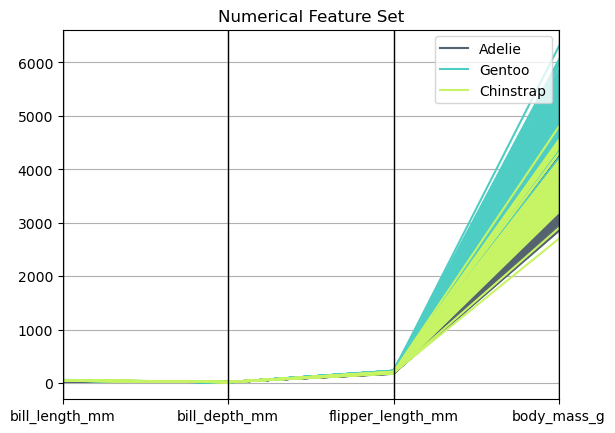

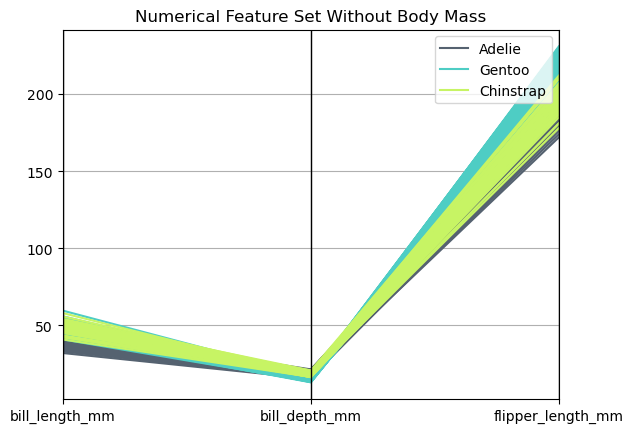

In [34]:
cols = list(ps.columns)

pd.plotting.parallel_coordinates(ps, class_column="species", cols=cols[2::], color=("#556270", "#4ECDC4", "#C7F464"))
plt.title("Numerical Feature Set")
plt.show()
cols.remove("body_mass_g")

pd.plotting.parallel_coordinates(ps, class_column="species", cols=cols[2::], color=("#556270", "#4ECDC4", "#C7F464"))
plt.title("Numerical Feature Set Without Body Mass")
plt.show()


(6) Versuchen Sie, mithilfe von geschicktem Slicing der verschiedenen Features im Parallel Coordinates Plot die jeweiligen Gattungen zu identifizieren. Orientieren Sie sich gerne an Ihren Ergebnissen bzw. Intervallen aus Teilaufgabe (4).

In [35]:
def print_data(species, ps):
    print(f"{species}: Bill Length\n {ps[ps['species'] == species]['bill_length_mm'].describe()}")
    print(f"{species}: Bill Depth\n {ps[ps['species'] == species]['bill_depth_mm'].describe()}")
    print(f"{species}: Flipper Length\n {ps[ps['species'] == species]['flipper_length_mm'].describe()}")
    print(f"{species}: Body Mass\n {ps[ps['species'] == species]['body_mass_g'].describe()}")
    print("\n")

print_data("Adelie", ps)
print_data("Chinstrap", ps)
print_data("Gentoo", ps)


Adelie: Bill Length
 count    151.000000
mean      38.791391
std        2.663405
min       32.100000
25%       36.750000
50%       38.800000
75%       40.750000
max       46.000000
Name: bill_length_mm, dtype: float64
Adelie: Bill Depth
 count    151.000000
mean      18.346358
std        1.216650
min       15.500000
25%       17.500000
50%       18.400000
75%       19.000000
max       21.500000
Name: bill_depth_mm, dtype: float64
Adelie: Flipper Length
 count    151.000000
mean     189.953642
std        6.539457
min      172.000000
25%      186.000000
50%      190.000000
75%      195.000000
max      210.000000
Name: flipper_length_mm, dtype: float64
Adelie: Body Mass
 count     151.000000
mean     3700.662252
std       458.566126
min      2850.000000
25%      3350.000000
50%      3700.000000
75%      4000.000000
max      4775.000000
Name: body_mass_g, dtype: float64


Chinstrap: Bill Length
 count    68.000000
mean     48.833824
std       3.339256
min      40.900000
25%      46.350000


(7) Versuchen Sie nun, bessere "Bounding Boxes" zu finden, um die Gattungen besser voneinander zu trennen. Betrachten Sie dabei insbesondere Features, die in der vorherigen Aufgabe nicht verwendet wurden. *(Zur Erinnerung: bisher wurden nur numerische Features betrachtet.)*

(8) Vergleichen Sie die beiden Visualisierungen und diskutieren Sie die Vor- und Nachteile der beiden Ansätze. 

### 5.3 Zusammenhangsmaße (Teil 1): Spearman vs Pearson

In dieser Übung werden wir synthetische Daten generieren und damit Spearmans- und Pearsons Korrelationskoeffizienten untersuchen.

**Ihre Daten**

Bei den Daten handelt es sich um die berühmte Fibonacci-Folge, eine unendliche Folge, die vom italienischen Mathematiker Leonardo Fibonacci im 12. Jahrhundert zur Beschreibung der Entwicklung einer Kaninchenpopulation aufgestellt wurde. 

Sei $y_n$ das n-te Glied der Folge und seien $y_1 = 0$ und $y_2 = 1$. Dann ist $y_n$ für $n\geq 3$ definiert als $$y_n = y_{n-1} + y_{n-2}.$$


**Ihre Aufgaben**

Nutzen Sie hauptsächlich Numpy (und ein wenig Pandas) zur Bearbeitung dieser Aufgaben.

(1) Schreiben eine Funktion, die für einen gegebenen Wert $n\in\mathbb{N}$ das Glied der Fibonacci-Folge zurückgibt.

In [36]:
def fib_(n, memo={}):
    if n in memo:
        return memo[n]
    if n == 1 or n == 2:
        return 1
    else:
        result = fib_(n - 1, memo) + fib_(n - 2, memo)
        memo[n] = result
        return result


def fib(n):
    return fib_(n, memo={})


fib(50)


12586269025

(2) Erzeugen Sie Ihren Datensatz. Sei $n = \{1, \ldots, 30\}$. Erstellen Sie mit Ihrer Funktion aus Schritt (1) die Folge $y_n$ für alle $n$. Sie erhalten damit Wertepaare $(n, y_n)$, die Sie z.B. in einem Numpy Array hinterlegen können.

In [39]:
data = np.array([[n, fib(n)] for n in range(1, 31)])

data[::, 0]

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30])

(3) Implementieren Sie eine Funktion, die zwei Datenreihen entgegennimmt und Pearsons Korrelationskoeffizient zurückgibt.

In [41]:
def pearson_correlation(data):
    return np.corrcoef(data[::, 0], data[::, 1])[0,1]


np.float64(0.603487879670368)

(4) Bestimmen Sie dann den Pearson Korrelationskoeffizienten zwischen der Datenreihe ${n}$ und ${y_n}$ mithilfe Ihrer Funktion aus (3) und notieren Sie sich den Wert.

In [42]:

cor = pearson_correlation(data)
cor

np.float64(0.603487879670368)

(5) Kopieren Sie sich den Code aus Schritt (3) und erzeugen Sie daraus eine neue Funktion, die Spearmans Korrelationskoeffizienten implementiert. Um die Ränge zu berechnen, können Sie Pandas `rank` Funktion nutzen.

In [44]:
from math import sqrt

def spearman_correlation(data):
    X = data[:, 0]
    Y = data[:, 1]

    n = len(X)

    rank_X = np.argsort(np.argsort(X)) + 1
    rank_Y = np.argsort(np.argsort(Y)) + 1

    mean_rank = (n + 1) / 2  # mean of ranks 1..n

    def cov():
        s = 0
        for i in range(n):
            s += (rank_X[i] - mean_rank) * (rank_Y[i] - mean_rank)
        return s

    def std(rank):
        s = 0
        for i in range(n):
            s += (rank[i] - mean_rank) ** 2
        return sqrt(s)

    return cov() / (std(rank_X) * std(rank_Y))


(6) Nutzen Sie Ihre Funktion aus Schritt (5), um Spearmans Korrelationskoeffizient zwischen $n$ und $y_n$ zu berechnen, die Sie in Schritt (2) erzeugt hatten.

In [45]:
spearman_correlation(data)

np.float64(1.0000000000000002)

(7) Vergleichen Sie den Wert von Pearsons Korrelationskoeffizienten (aus Schritt 4) mit dem Wert von Spearmans Korrelationskoeffizienten (aus Schritt 6). Was fällt Ihnen auf? (1 Satz). Was ist die Ursache für den Unterschied zwischen beiden Werten, den Sie feststellen? (1-3 Sätze)  

In [ ]:
'''
Man kann einen deutlichen Unterschied zwischen den beiden Korrelationen erkennen. Die Pearson-Korrelation ist sehr hoch, da die Fibonacci-Folge 
eine exponentielle Wachstumskurve darstellt, die stark mit der Anzahl der Elemente korreliert. Die Spearman-Korrelation ist jedoch niedriger, da sie die 
Rangordnung der Daten berücksichtigt und die Fibonacci-Folge nicht linear ist.
'''

### 5.4 Zusammenhangsmaße (Teil 2): Mutual Information, Pearson, Spearman

In dieser Übung werden Sie Zusammenhänge zwischen verschiedenen Datensätzen mithilfe der Zusammenhangsmaße untersuchen, die Sie in der Vorlesung kennengelernt haben. Daneben werden Sie vertraut mit dem Importieren von Daten aus Excel-Tabellen.

* Nutzen Sie Pandas und Numpy zum Bearbeiten der folgenden Aufgaben.

**Ihre Daten**

* Sie finden die Daten, die Sie für diese Übung benötigen, im Git Repository unter `data/dependency_data.xlsx`.

**Ihre Aufgaben**

(1) Importieren Sie die Daten mithilfe der [Funktionalität](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_excel.html) von Pandas in einen DataFrame.

* Visualisieren Sie die Daten zunächst **nicht** (aus didaktischen Gründen). Sie werden die Daten erst im Teilschritt (5) visualisieren.

In [63]:
data = pd.read_excel("../data/dependency_data.xlsx")

def get2d(data, col, col2):
    return np.array([[data[col][i], data[col2][i]] for i in range(len(data[col]))])


(2) Wir betrachten im Folgenden Paare von Spalten, beispielsweise $(X, y_1)$, die wir *Datenreihenpaare* nennen werden.

Berechnen Sie mit Ihrem Code aus Übung 4 den Pearson- sowie den Spearman-Korrelationskoeffizienten für die Datenreihenpaare ...

1. $(X, y_1)$
2. $(X, y_2)$
3. $(X, y_3)$
4. $(X, y_4)$

In [66]:
print(f' Spearman (X, y1): {spearman_correlation(get2d(data, "X", "y1"))}')
print(f' Spearman (X, y2): {spearman_correlation(get2d(data, "X", "y2"))}')
print(f' Spearman (X, y3): {spearman_correlation(get2d(data, "X", "y3"))}')
print(f' Spearman (X, y4): {spearman_correlation(get2d(data, "X", "y4"))}')

 Spearman (X, y1): 0.04192822192822193
 Spearman (X, y2): 0.03621319221319221
 Spearman (X, y3): -0.726994086994087
 Spearman (X, y4): 0.0187003867003867


(3) Beantworten Sie - ohne zu Visualisieren - anhand der Koeffizienten aus Teilaufgabe (2):

* Welche der Datenreihenpaare zeigen Korrelationen? (X,y3)
* Welche Datenreihenpaare sind unkorreliert? (X,y1), (X,y2), (X,y4)
* Gibt es Widersprüche zwischen den Korrelationskoeffizienten? Falls ja, für welche Daten?

(4) Bestimmen Sie nun für die in Teilaufgabe (2) genannten Datenreihenpaare jeweils die Mutual Information. Ausgehend von Ihren Werten für die Mutual Information beantworten Sie bitte: Zwischen welchen Datenreihenpaaren gibt es Zusammenhänge, zwischen welchen Datenreihenpaare gibt es keine (großen) Zusammenhänge?

* Nutzen Sie für die Bestimmung der *Mutual Information* die [Implementierung](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.mutual_info_regression.html) der scikit-learn Bibliothek. Hintergrund: Eine robuste Schätzung der Mutual Information ist anspruchsvoll und wurde von verschiedenen Forschungsgruppen untersucht. Einer der [weltweit bekanntesten Schätzer](https://journals.aps.org/pre/pdf/10.1103/PhysRevE.69.066138) der Mutual Information wurde von Forschern des Forschungszentrum Jülichs (am John von Neumann-Institut für Computing) im Jahr 2004 publiziert und wird auch von scikit-learn implementiert.

In [75]:
from sklearn.feature_selection import mutual_info_regression 

X = data["X"].values.reshape(-1, 1)

print(f'Mutual (X, y1): {mutual_info_regression(X, data["y1"])[0]:.4f}')
print(f'Mutual (X, y2): {mutual_info_regression(X, data["y2"])[0]:.4f}')
print(f'Mutual (X, y3): {mutual_info_regression(X, data["y3"])[0]:.4f}')
print(f'Mutual (X, y4): {mutual_info_regression(X, data["y4"])[0]:.4f}')


Mutual (X, y1): 0.8464
Mutual (X, y2): 0.8866
Mutual (X, y3): 2.5489
Mutual (X, y4): 0.0207


(5) Visualisieren Sie nun alle Datenreihenpaare aus Teilaufgabe (2) in Scatterplots und beschriften Sie jeden Plot mit den entsprechenden Werten des Pearson-, Spearman-Korrelationskoeffizienten und dem Wert der Mutual Information.

Text(0, 0.5, 'y4')

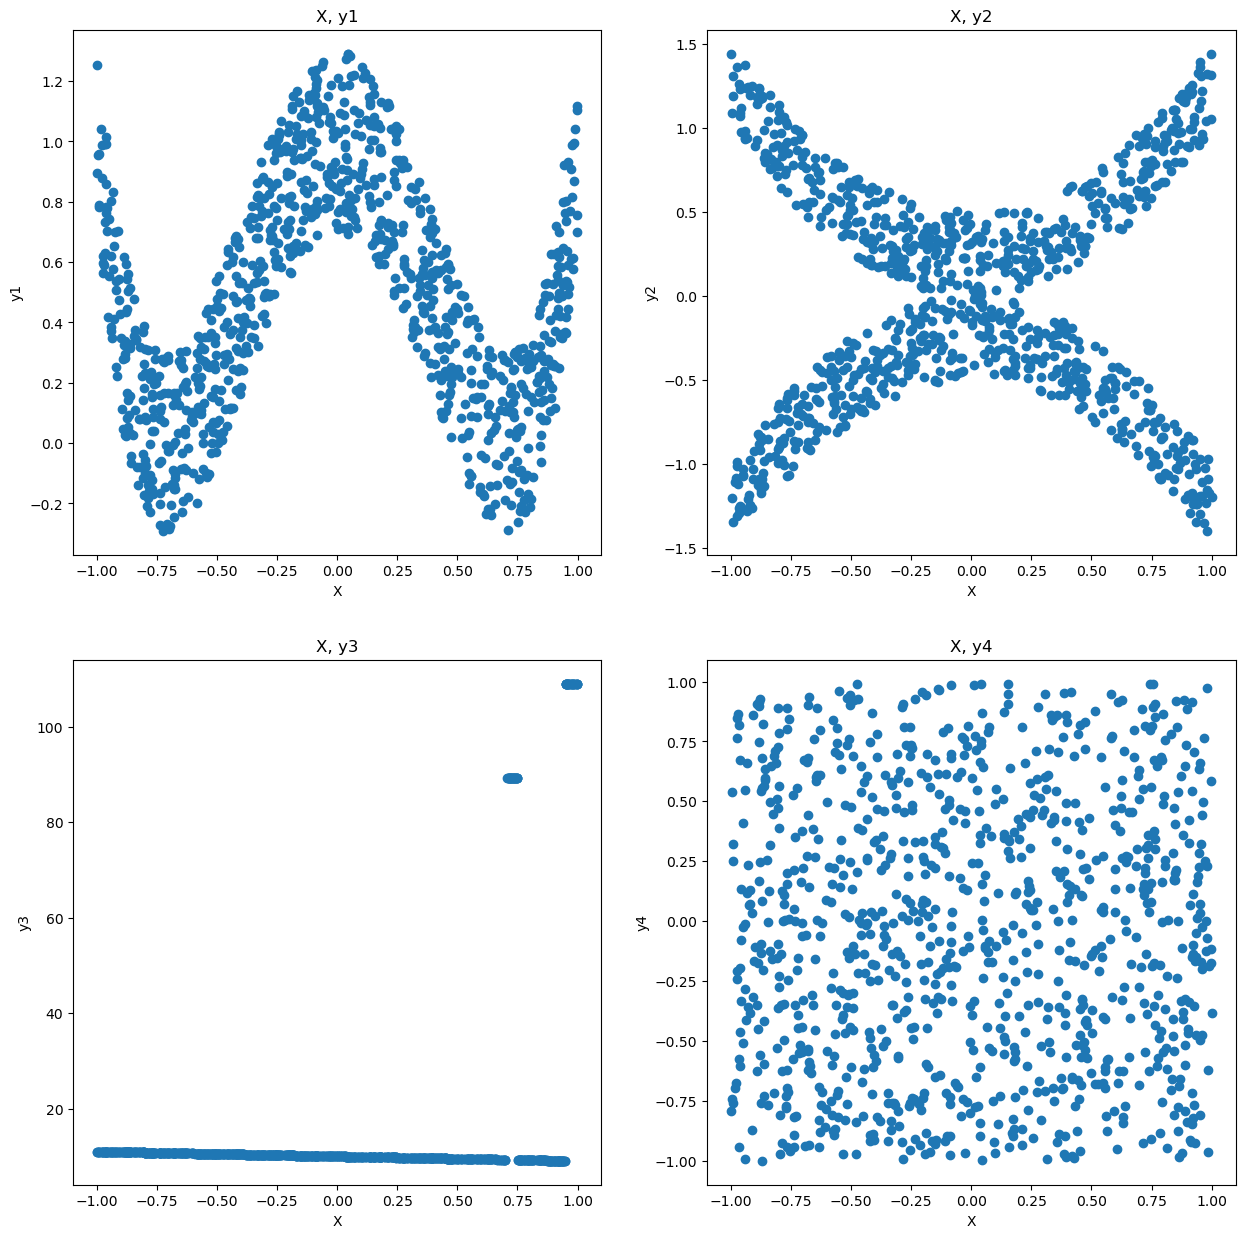

In [71]:

fig, ax = plt.subplots(2,2, figsize=(15,15))

ax[0, 0].scatter(data["X"], data["y1"])
ax[0, 0].set_title("X, y1")
ax[0, 0].set_xlabel("X")
ax[0, 0].set_ylabel("y1")

ax[0, 1].scatter(data["X"], data["y2"])
ax[0, 1].set_title("X, y2")
ax[0, 1].set_xlabel("X")
ax[0, 1].set_ylabel("y2")

ax[1, 0].scatter(data["X"], data["y3"])
ax[1, 0].set_title("X, y3")
ax[1, 0].set_xlabel("X")
ax[1, 0].set_ylabel("y3")

ax[1, 1].scatter(data["X"], data["y4"])
ax[1, 1].set_title("X, y4")
ax[1, 1].set_xlabel("X")
ax[1, 1].set_ylabel("y4")

(6) Begründen Sie nun für jedes Datenreihenpaar, warum Sie Korrelationen oder keine Korrelation durch Pearson, Spearman und die Mutual Information angezeigt bekommen.

* Begründen Sie zusätzlich, warum Sie für Datenreihenpaar $(X, y_3)$ so unterschiedliche Ergebnisse für den Pearson- und den Spearman-Korrelationskoeffizienten erhalten haben.